# Creating AI without such libraries as Torch or TensorFlow

## Children Stories

In [1]:
from NoTorchAI.Utils.Batch import Batch


datasets = {
    "children_stories": ("env/encoded/children_stories.bin", "pure", 1.0),
}

batch = Batch(datasets, "env/tokenizer.json")

In [ ]:
from NoTorchAI.GlobalState.Device import Device
from NoTorchAI.GlobalState.Quant import Quant
from NoTorchAI.Gradients.Adam import Adam
from NoTorchAI.LLM.MiniGPT import MiniGPT
from NoTorchAI.Utils.TrainGPT import TrainGPT


d_model = 384
n_heads = 8
block_layers = 7
block_size = 128

batch_size = 56
vocabulary_size = 16_000

Device("gpu")
Quant(32)

gradient = Adam(
    lr=8e-5,
    warmup_steps=1000,
    min_lr=8e-6,
)

model = MiniGPT(vocab_size=vocabulary_size, 
                d_model=d_model, 
                block_size=block_size,
                n_layers=block_layers,
                n_heads=n_heads,
                gradient=gradient
            )

gpt = TrainGPT(model=model, 
               gradient=gradient, 
               batch=batch, 
               block_size=block_size, 
               batch_size=batch_size, 
               tokenizer_path="env/tokenizer.json",
               save_path="saved_model")

gpt.train(prompt="Water heats", 
          max_tokens=100, 
          output_sample_step=500, 
          gradient_sample_step=200, 
          end_step=10_000)

Once upone a time a dragon named Bob. He was very excited to play in the park. He had a big, blue ball that was a car. He liked to play with it too.One day, Binky saw a big red ball. He wanted to play with the ball, but it was too high. He thought of a plan to play with the ball. He took the ball and rolled it. The ball rolled, and rolled it hit the ball. The ball rolled into the puddle
step 8700, lr 0.000080, loss 2.6203, ema_loss 2.5840
Once upone a time a dragon. One day, he was very excited. He wanted to find a big, so he asked his friend, the bear, to help him.The farmer was very excited and asked his friend, the bear."Can you help me help me?" asked the bear. The bear gave him a big hug and said, "Yes, I can help you. I can help you."The bear was very happy and said, "Yes, you can help me. We
step 8800, lr 0.000080, loss 2.5469, ema_loss 2.5772
Once upone a time a dragon named Bob. He was very excited. He wanted to go on a big rock. He asked his mom, "Can I ride the rock?" His mo

## Story Instruct

In [3]:
from NoTorchAI.Utils.Batch import Batch


datasets = {
    "children_stories": ("env/encoded/children_stories.bin", "pure", 0.30),
    "simple_wikipedia": ("env/encoded/stories_instructions.bin", "instruct", 0.70),
}

batch = Batch(datasets, "env/tokenizer.json")

In [4]:
from NoTorchAI.GlobalState.Device import Device
from NoTorchAI.GlobalState.Quant import Quant
from NoTorchAI.Gradients.Adam import Adam
from NoTorchAI.LLM.MiniGPT import MiniGPT
from NoTorchAI.Utils.TrainGPT import TrainGPT


Device("gpu")
Quant(32)

block_size = 128
batch_size = 56

model = MiniGPT.__new__(MiniGPT)
model: MiniGPT = model.load("saved_model")

gradient = Adam(
    lr=1e-6,
    warmup_steps=200,
    min_lr=1e-8,
)

gpt = TrainGPT(model=model, 
               gradient=gradient, 
               batch=batch, 
               block_size=block_size, 
               batch_size=batch_size, 
               tokenizer_path="env/tokenizer.json",
               save_path="story_instruct_masking_model")

gpt.train(prompt="<|user|>: Tim went out of the house and found himeself in the woods\n<|assistant|>:",
          max_tokens=100,
          temperature=0.8,
          output_sample_step=500, 
          gradient_sample_step=200,
          end_step=10_000)

step 0, lr 0.000000, loss 2.3474, ema_loss 2.3474
: Tim went out of the house and found himeself in the woods
: a big, red ball. Tom was very excited; he had never seen any more and kept his pet carry until it made her side.One day, for packing all his animals to see what Tom did with his hands. He put on the finish line of going to play with his friends when they came back home and told them about their fun adventure in time. From that day onwards, he always
step 1, lr 0.000000, loss 2.3351, ema_loss 2.3473
step 200, lr 0.000001, loss 2.1197, ema_loss 2.2946
step 400, lr 0.000001, loss 2.2735, ema_loss 2.2695
: Tim went out of the house and found himeself in the woods
: "I am so proud! Let's go see!"So, Tim picked a picture of his car and started to draw. But then, something unexpected happened. A big bird flew into the sky and landed on it too! The bird said, "Hello are you little boy," Tim quickly told her about his growing bracelet that day. From that day on, they both Here she mad

## Play ground

In [1]:
from NoTorchAI.LLM.MiniGPT import MiniGPT
from NoTorchAI.Utils.TrainGPT import TrainGPT
from NoTorchAI.Utils.Batch import Batch
from NoTorchAI.Gradients.Adam import Adam


datasets = {
    "children_stories": ("env/encoded/children_stories.bin", "pure", 1.0),
}

batch = Batch(datasets, "env/tokenizer.json")

block_size = 128
batch_size = 56

gradient = Adam(
    lr=1e-5,
    warmup_steps=300,
    min_lr=1e-6,
)


model = MiniGPT.__new__(MiniGPT)
model: MiniGPT = model.load("story_instruct_model")


gpt = TrainGPT(model=model, 
               gradient=gradient, 
               batch=batch, 
               block_size=block_size, 
               batch_size=batch_size, 
               tokenizer_path="env/tokenizer.json",
               save_path="test")

In [31]:
gpt.generate_str(prompt='<|user|>: Tom is climbing a tree\n<|assistant|>:',
                 max_tokens=128,
                 temperature=0.6,
                 repetition_penalty=1.2)

': Tom is climbing a tree\n:Tom and Lily were playing in the park. They liked to run, jump and slide down. They saw a big bush with many leaves on it. It was very pretty and had many colors on them!"Look, Lily!" Tom said softly as he climbed up the branches. "I am so high that we can climb."Lily smiled too, but she wanted to see what would happen next time for him to reach it alone while she could climb down the tree again soon climbed higher than ever before!They reached out her palm trees while they were there but they couldn\'t find their way back'

## Statistics

Working on k: 25
Working on k: 50
Working on k: 75
Working on k: 100
Working on k: 125
Working on k: 150
Working on k: 175
Working on k: 200
Working on k: 225
Working on k: 250
Working on k: 275
Working on k: 300
Working on k: 325
Working on k: 350
Working on k: 375
Working on k: 400
Working on k: 425


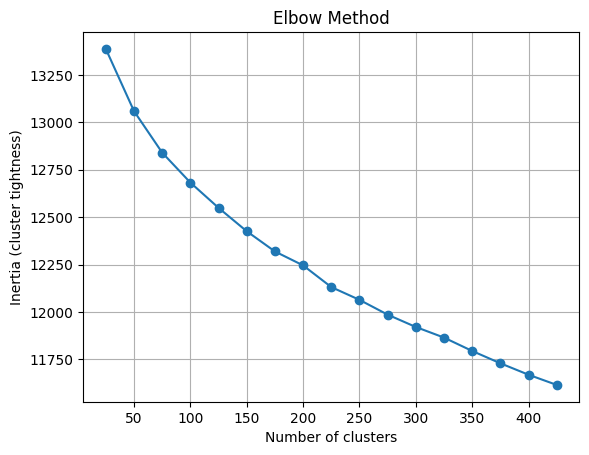

In [5]:
import numpy as np
import matplotlib.pyplot as plt

from NoTorchAI.Stats.KNN import KNN


embeddings = model.initial_embedding.token_embedding.embeddings.get()

check_ks = [25 * i for i in range(1, 18)]

results = []
for k in check_ks:
    print(f"Working on k: {k}")
    clusters, centroids = KNN.get_clusters(k, embeddings)

    cluster_elbows = []
    for i, cluster in clusters.items():
        centroid = centroids[i]
        cluster_elbows.append(np.sum([KNN.cosine_distance(embeddings[embedding_id], centroid) for embedding_id in cluster]))

    results.append(np.sum(cluster_elbows))


plt.figure()
plt.plot(check_ks, results, marker="o")

plt.xlabel("Number of clusters")
plt.ylabel("Inertia (cluster tightness)")
plt.title("Elbow Method")

plt.grid()
plt.show()

In [45]:
from tokenizers import Tokenizer
from tokenizers.decoders import ByteLevel


tokenizer = Tokenizer.from_file("env/tokenizer.json")
tokenizer.decoder = ByteLevel()

clusters, centroids = KNN.get_clusters(150, embeddings)

decoded_clusters = {}
for i, cluster in clusters.items():
    decoded_cluster = [tokenizer.id_to_token(emb_id) for emb_id in cluster]
    print(f"Id {i}: {decoded_cluster[:50]}")

Id 0: ['8', 'er', 'ed', 'ion', 'ir', 'ation', 'Ġsaid', 'ore', 'out', 'ep', 'Ġtoo', 'ine', 'ough', 'ase', 'ble', 'uch', 'Ġfirst', 'Ġsad', 'Ġsays', 'Ġaway', 'ank', 'Ġsay', 'Ġhand', 'Ġscared', 'led', 'Ġhead', 'Ġleg', 'Ġhappened', 'Ġbad', 'ern', 'orry', 'Ġground', 'less', 'Ġmean', 'icked', 'Ġsorry', 'ider', 'ister', 'ĠMr', 'Ġface', 'ode', 'Ġfight', 'Ġmess', 'Ġsound', 'Ġpain', 'No', 'Ġattack', 'Ġunderstand', 'Ġhurt', 'work']
Id 1: ['Ö', 'å', 'rom', 'ark', 'ff', 'ult', 'ense', 'Ġrecent', 'Ġcreat', 'ories', 'âĢ¦', 'angu', 'ĠIntern', 'Ġposition', 'Ġcoup', 'ĠRom', 'Ġess', 'ĠTH', '27', 'yal', 'Ġproduce', 'EM', 'Ġterrit', 'rary', 'Ġvotes', 'Ġcapacity', 'sex', ',[', 'apping', 'utch', 'Ġabandon', 'Ġcampus', 'ĠAsian', 'Ġregions', 'ece', 'Ġregistered', 'ĠConf', '."[', 'Ġtechnique', 'ĠSS', 'ĠPent', 'gus', 'Ġthorough', 'ĠFall', 'Ġblockchain', 'Ġengineers', 'ĠIntel', 'à¸', 'Ġblend', 'ĠChristopher']
Id 2: ['Ê', 'il', 'Ġdifferent', 'Ġclaim', 'Ġ=', 'ĠState', 'Ġsum', '.,', 'ann', 'Ġrights', 'lebr', 'ipe', '

In [46]:
import random

from NoTorchAI.Stats.PCA import PCA

selected_cluster_ids = [133, 93, 86, 125] # random.sample(list(clusters.keys()), 4)

points = []
labels = []
point_ids = []

for cid in selected_cluster_ids:
    for emb_id in clusters[cid]:
        points.append(embeddings[emb_id])
        labels.append(cid)
        point_ids.append(emb_id)

points = np.array(points)
labels = np.array(labels)

points_2d = PCA.reduce_dimensions(points, 2)

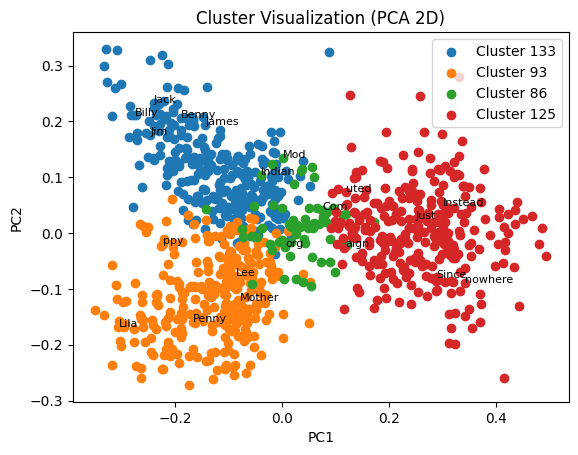

In [ ]:
import matplotlib.pyplot as plt

plt.figure()

# map cluster id to group
cluster_mapping = {
    133: "Boys",
    93: "Girls",
    125: "Stop words",
    86: "Government"
}

for cid in selected_cluster_ids:
    cluster_points = points_2d[labels == cid]
    cluster_indices = np.where(labels == cid)[0]

    plt.scatter(cluster_points[:, 0], cluster_points[:, 1], label=f"{cluster_mapping[cid]}")

    # pick random points to label
    num_labels = min(5, len(cluster_indices))
    chosen = random.sample(list(cluster_indices), num_labels)

    for idx in chosen:
        x, y = points_2d[idx]
        token = tokenizer.id_to_token(point_ids[idx])

        # clean token a bit
        token = token.replace("Ġ", "")

        plt.text(x, y, token, fontsize=8)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Cluster Visualization (PCA 2D)")
plt.legend()
plt.show()